In [3]:
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image
from pathlib import Path

tf.keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


### EDA

Datasetet FER-2013 innehåller gråskalebilder (48x48 pixlar) av ansikten uppdelade i 7 klasser av ansiktsuttryck.

Datasetet är redan uppdelat i tränings- och testdata, så ingen egen train/test-split behövs.

Klasser: angry, disgust, fear, happy, neutral, sad, surprise

Antal bilder:
- Träning: 28 700 bilder
- Test: 7 200 bilder

Klasserna är tydligt obalanserade. Happy är den största klassen med 7 215 träningsbilder, 
medan disgust bara har 436. 
Det innebär att modellen riskerar att bli bättre på vanliga klasser och sämre på disgust.

In [4]:
# titta på datans struktur
# datasetet är redan uppdelat i train och test, så behöver inte göra egen train/test split
# 7 klasser: angry, disgust, fear, happy, neutral, sad, surprise
# Klasserna är obalanserade. Många fler happy bilder än disgust tex
# 28 700 träningsbilder och 7 200 testbilder

#happy: 7215 bilder
#disgust: 436 bilder

data_path = "data/FER-2013"

for split in ["train", "test"]:
    path = os.path.join(data_path, split)
    classes = [c for c in os.listdir(path) if not c.startswith(".")]    # så att vi inte får problem med .DS_Store på macOS
    print(f"\n{split}:")
    for c in sorted(classes):
        n = len(os.listdir(os.path.join(path, c)))
        print(f"  {c}: {n} bilder")


train:
  angry: 3995 bilder
  disgust: 436 bilder
  fear: 4097 bilder
  happy: 7215 bilder
  neutral: 4965 bilder
  sad: 4830 bilder
  surprise: 3171 bilder

test:
  angry: 958 bilder
  disgust: 111 bilder
  fear: 1024 bilder
  happy: 1774 bilder
  neutral: 1233 bilder
  sad: 1247 bilder
  surprise: 831 bilder


### Förbereda datan

Bilderna laddades in som numpy arrays och normaliserades till värden mellan 0 och 1.

Eftersom klasserna är obalanserade skapades ett balanserat subset med 300 bilder 
per klass, totalt 2100 bilder.

Subset delades upp i tränings- och valideringsdata:
- Träning: 1680 bilder (80%)
- Validering: 420 bilder (20%)

Testdatan (7178 bilder) behålls helt osedd tills den slutliga utvärderingen.

In [5]:
# Ladda in tränings- och testdata
train_dataset = keras.utils.image_dataset_from_directory(       # inbyggd Keras funktion som laddar in bilderna
    "data/FER-2013/train",
    image_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    label_mode="int",
    shuffle=True,
    seed=42
)

test_dataset = keras.utils.image_dataset_from_directory(
    "data/FER-2013/test",
    image_size=(48, 48),
    batch_size=64,
    color_mode="grayscale",
    label_mode="int",
    shuffle=False,
    seed=42
)

class_names = train_dataset.class_names
print("Klasser:", class_names)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Klasser: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [6]:
# Ladda in bilder som numpy arrays
# ett alternativ hade varit att använda image_dataset_from_directory() 
# men jag känner mig mer komfortable med numpy arrays

# 28 709 träningsbilder, 7 178 testbilder
# 48x48 pixlar med 1 kanal (gråskala)

def load_images_from_folder(base_path, class_names):
    X = []
    y = []
    
    for class_id, class_name in enumerate(class_names):
        folder = Path(base_path) / class_name
        for img_path in folder.glob("*.jpg"):
            img = image.load_img(img_path, target_size=(48, 48), color_mode="grayscale")
            img_array = image.img_to_array(img)
            X.append(img_array)
            y.append(class_id)
    
    return np.array(X), np.array(y)

class_names = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

X_train_full, y_train_full = load_images_from_folder("data/FER-2013/train", class_names)
X_test, y_test = load_images_from_folder("data/FER-2013/test", class_names)

print("X_train_full:", X_train_full.shape)
print("y_train_full:", y_train_full.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train_full: (28709, 48, 48, 1)
y_train_full: (28709,)
X_test: (7178, 48, 48, 1)
y_test: (7178,)


In [7]:
# Normalisera pixelvärden från [0, 255] till [0, 1]
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0

print("Min pixelvärde:", X_train_full.min())
print("Max pixelvärde:", X_train_full.max())

Min pixelvärde: 0.0
Max pixelvärde: 1.0


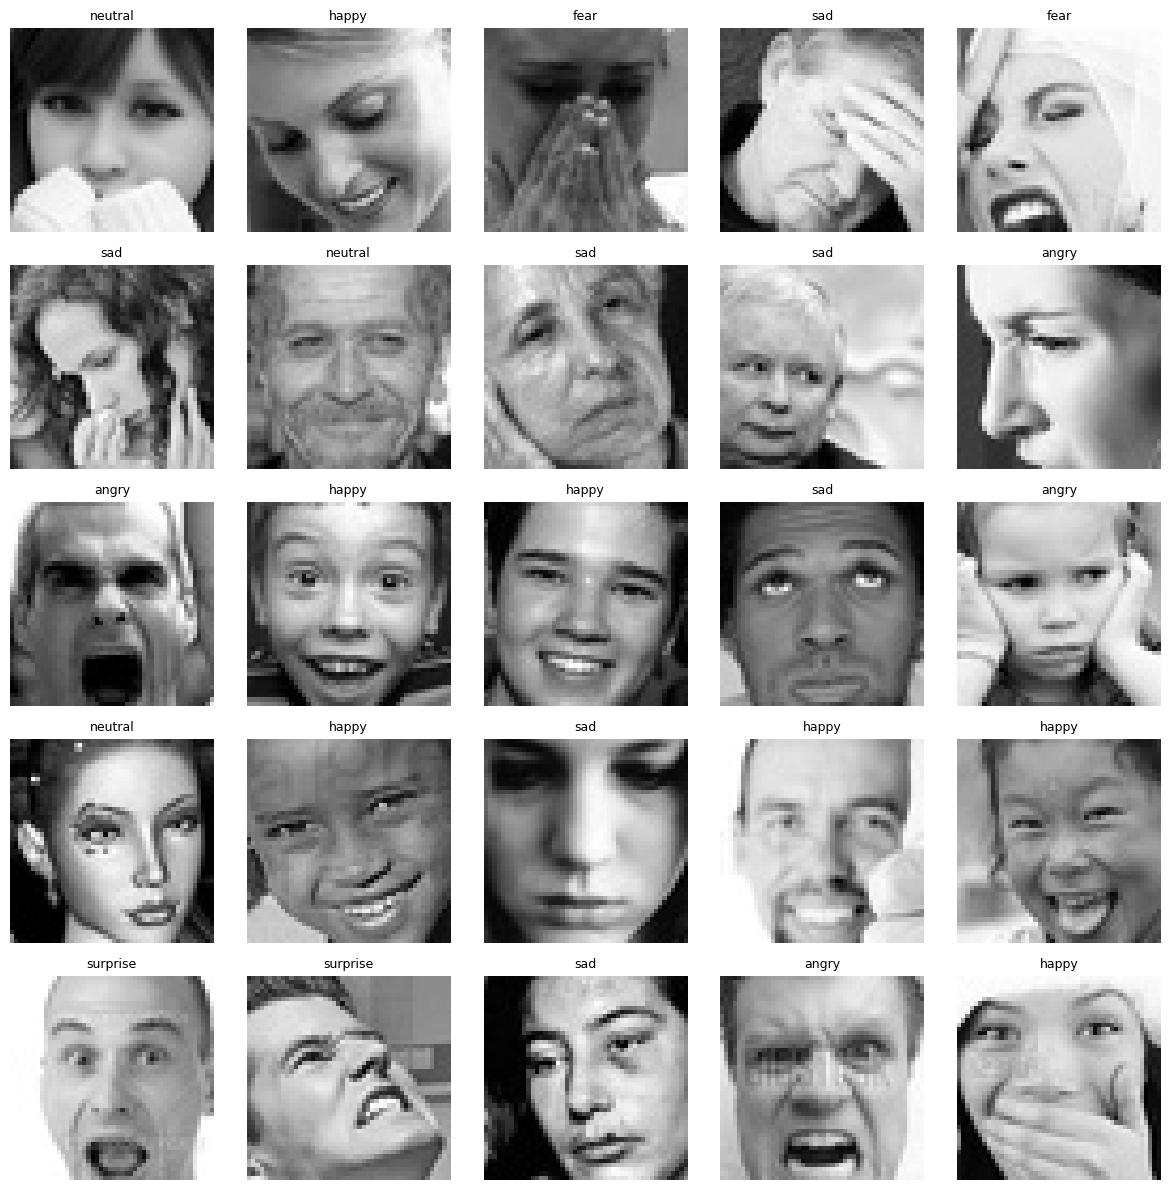

In [8]:
# titta på några exempelbilder
# tar ut 25 slumpmässiga bilder fråpn train

def plot_image_grid(X, y, class_names, n_images=25, random_state=42):
    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images)))

    plt.figure(figsize=(12, 12))
    
    for plot_index, image_index in enumerate(indices):
        plt.subplot(grid_size, grid_size, plot_index + 1)
        plt.imshow(X[image_index].squeeze(), cmap="gray")
        plt.title(class_names[y[image_index]], fontsize=9)
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

plot_image_grid(X_train_full, y_train_full, class_names, n_images=25)

In [9]:
# Skapa ett balanserat subset av datan
# Använder 300 slumpmässiga bilder per klass
# så shapen blir 300 x 7, 48 x 48 pixlar och en kanal

def create_balanced_subset(X, y, samples_per_class=300, random_state=42):
    rng = np.random.default_rng(random_state)
    selected_indices = []

    for class_id in np.unique(y):
        class_indices = np.where(y == class_id)[0]

        if len(class_indices) < samples_per_class:
            raise ValueError(
                f"Klassen {class_id} har bara {len(class_indices)} exempel, "
                f"men samples_per_class={samples_per_class}"
            )
        
        chosen_indices = rng.choice(
            class_indices,
            size=samples_per_class,
            replace=False
        )

        selected_indices.extend(chosen_indices)
    
    selected_indices = np.array(selected_indices)
    rng.shuffle(selected_indices)

    return X[selected_indices], y[selected_indices]


X_subset_raw, y_subset = create_balanced_subset(
    X_train_full,
    y_train_full,
    samples_per_class=300,
    random_state=42
)

print("X_subset:", X_subset_raw.shape)
print("y_subset:", y_subset.shape)

X_subset: (2100, 48, 48, 1)
y_subset: (2100,)


In [10]:
# Delar upp subsetet i träning och validering 

X_train, X_val, y_train, y_val = train_test_split(
    X_subset_raw,
    y_subset,
    test_size=0.2,
    random_state=42,
    stratify=y_subset
)

print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)

Train shape: (1680, 48, 48, 1)
Val shape: (420, 48, 48, 1)


### Baseline-modell

Jag har medveter gjort baselinemodellen så enkel som möjligt, för att ha den som utgångspunkt mot de 
modellförbättringar jag sen gör. 

Modellen skiljer sig från den förbättrade modellen på tre sätt:
- Bara ett Conv2D-lager per block istället för två
- Inget tredje Conv2D-block
- Ingen Dropout

Avsaknaden av Dropout innebär att modellen troligen kommer att overfitta (träningsaccuracy kommer vara högre än valideringsaccuracy).
Genom att sen förbättra modellen ska vi kunna få den att presetera bättre på ny data. 

Baseline-modellen tränades på subset (1680 träningsbilder, 420 valideringsbilder) i 15 epochs.

- Träningsaccuracy: 79.6%
- Valideringsaccuracy: 33.1%

Modellen visar tecken på både underfitting och overfitting samtidigt.
Valideringsaccuracy på 33.1% är låg, vilket tyder på underfitting. Modellen är för enkel för att lära sig. 

Samtidigt syns tydlig overfitting redan efter epoch 2-3, där träningsaccuracy fortsätter klättra 
medan valideringsaccuracy planar ut. Dropout skulle antagligen ha hjälpt.

In [ ]:
# Bygg en baaseline
# CNN med två Conv2D-lager och MaxPooling, följt av ett Dense-lager

def build_baseline_model(num_classes, learning_rate=0.001):
    model = keras.Sequential([
        keras.Input(shape=(48, 48, 1)),

        # Ingen Dropout till att börja med
        # Bara ett Conv2D-lager per block för baseline
        # MaxPooling krymper bilden. Det minskar antalet parametrar så modellen tränar snabbare
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),
        

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Plattar ut 3D-tensor till 1D så att den kan matas in i Dense-lagret
        layers.Flatten(),

        # Denselagret på slutet
        layers.Dense(128, activation="relu"),

        # Ingen Dropout här
        # Använder softmax för att få sannorlikheter 
        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )

    return model

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)

num_classes = len(class_names)
baseline_model = build_baseline_model(num_classes=num_classes)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,495 (4.58 MB)

 Trainable params: 1,199,495 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Träna baseline modellen med 15 epoker och batch size 64

start_time = time.time()

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64
)

baseline_training_time = time.time() - start_time
print(f"Träningstid för baseline på subset: {baseline_training_time / 60:.2f} minuter")

Epoch 1/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.1292 - loss: 1.9519 - val_accuracy: 0.1619 - val_loss: 1.9422
Epoch 2/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.1815 - loss: 1.9268 - val_accuracy: 0.2024 - val_loss: 1.9536
Epoch 3/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.2893 - loss: 1.8303 - val_accuracy: 0.2476 - val_loss: 1.8976
Epoch 4/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.3607 - loss: 1.7197 - val_accuracy: 0.2619 - val_loss: 1.8758
Epoch 5/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.3970 - loss: 1.6244 - val_accuracy: 0.2929 - val_loss: 1.8496
Epoch 6/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4315 - loss: 1.5369 - val_accuracy: 0.2881 - val_loss: 1.8542
Epoch 7/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4655 - loss: 1.4462 - val_accuracy: 0.3000 - val_loss: 1.8750
Epoch 8/15
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.5173 - loss: 1.3438 - val_accuracy: 0.3048 - v

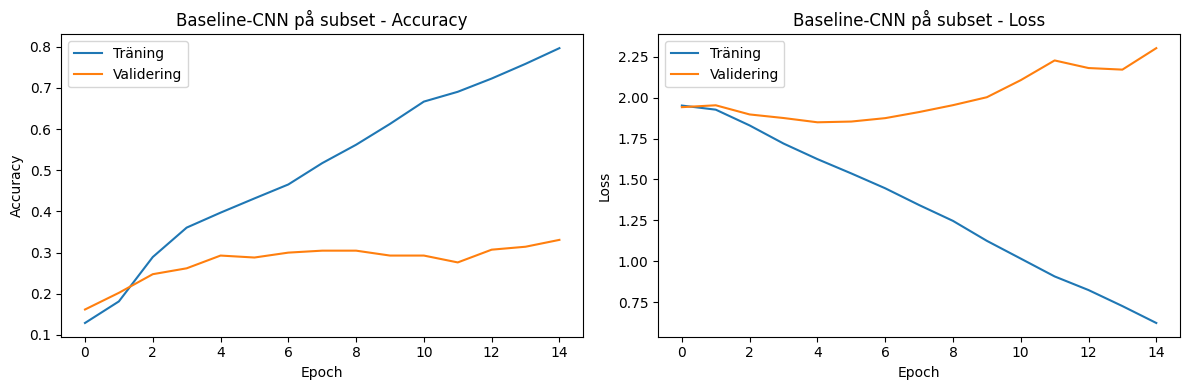

In [14]:
# Plotta träningskurvor för baseline
def plot_history(history, title="Träningshistorik"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Accuracy
    axes[0].plot(history.history["accuracy"], label="Träning")
    axes[0].plot(history.history["val_accuracy"], label="Validering")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    # Loss
    axes[1].plot(history.history["loss"], label="Träning")
    axes[1].plot(history.history["val_loss"], label="Validering")
    axes[1].set_title(f"{title} - Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(baseline_history, title="Baseline-CNN på subset")

In [16]:
# Felanalys på baseline modellen

# Starta med prediktioner på valideringsdatan

def predict_classes(model, X):
    y_proba = model.predict(X, verbose=0)
    y_pred = np.argmax(y_proba, axis=1)
    return y_pred, y_proba

baseline_val_pred, baseline_val_proba = predict_classes(baseline_model, X_val)

baseline_val_accuracy = accuracy_score(y_val, baseline_val_pred)
print(f"Baseline validation accuracy: {baseline_val_accuracy:.4f}")

Baseline validation accuracy: 0.3310


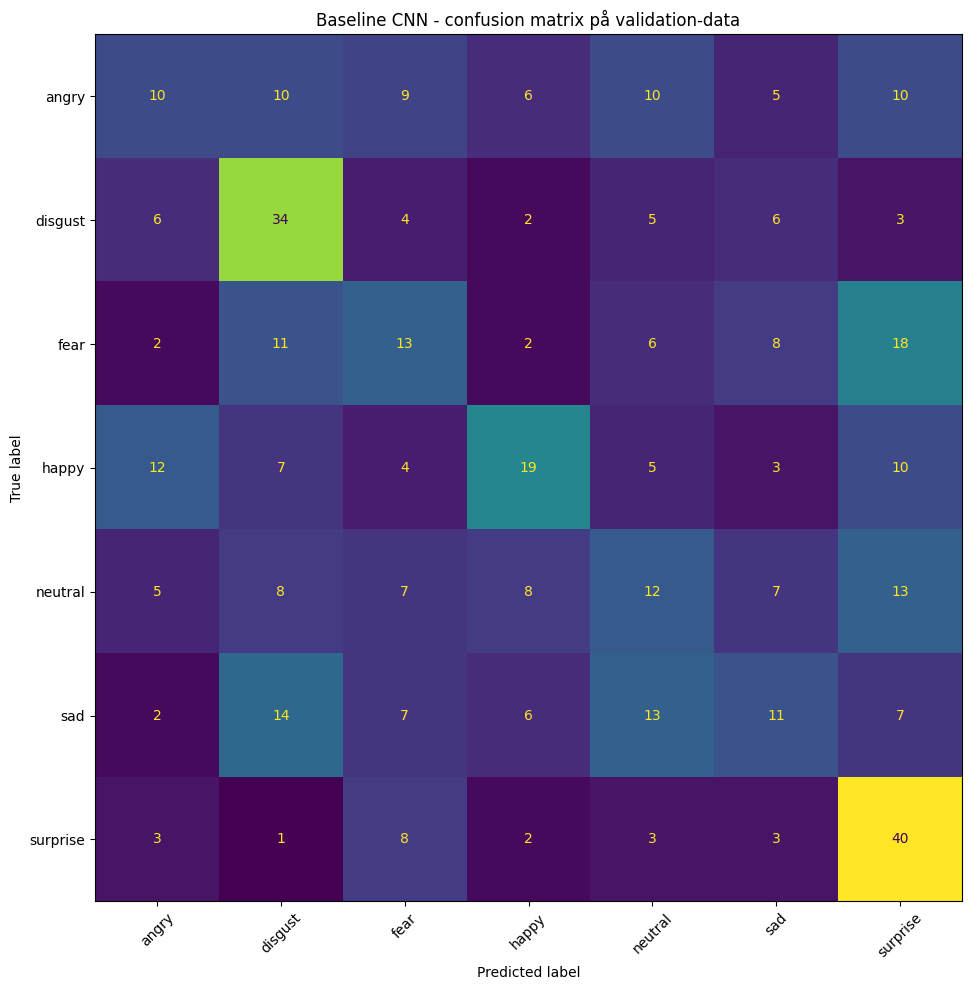

In [ ]:
# Confusion matrix för valideringsdatan

# Ser här att 
# surprise/surprise = 40 Modellen gissade rätt på 40 av surprise-bilderna. Surprise verkar vara den lättaste klassen att känna igen.
# angry/angry = 10 Modellen gissade bara rätt på 10 av angry-bilderna. Angry är svår att känna igen.
# fear/surprise = 18 Bilder som faktiskt var fear gissades som surprise. 

def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion matrix"):
    cm = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    
    return cm

baseline_cm = plot_confusion_matrix(
    y_val,
    baseline_val_pred,
    class_names,
    title="Baseline CNN - confusion matrix på validation-data"
)